# VietDoc — Fine-tune chữ viết tay trên Kaggle T4

Chạy lần lượt. Notebook thực hiện: chuẩn bị dữ liệu → baseline → fine-tune → test → xuất bundle local.
Dataset 5CD dùng CC BY-NC 4.0; dùng cho portfolio/nghiên cứu phi thương mại.
Không nhập token trực tiếp vào code. Thêm Secret `HF_TOKEN` trong Kaggle Add-ons → Secrets và bật quyền notebook.

Upload ZIP mã nguồn thành Kaggle Dataset **private**, rồi Add Input vào notebook. Chọn GPU T4, bật Internet.
Không chạy đồng thời baseline và training. Một T4 là đủ để bắt đầu batch 8, accumulation 4; nếu OOM giảm batch 4 hoặc 2.


In [3]:
from pathlib import Path
import shutil
import os
# 1. Tìm source project trong Kaggle Input
projects = list(
    Path("/kaggle/input").rglob("pyproject.toml")
)
print("Projects found:")
for p in projects:
    print(" -", p)
assert len(projects) >= 1, \
    "Không tìm thấy project trong /kaggle/input"
source_root = projects[0].parent
# 2. Copy sang writable workspace
root = Path("/kaggle/working/vietdoc-ocr")
if not root.exists():
    shutil.copytree(
        source_root,
        root
    )
# 3. Chuyển working directory
os.chdir(root)
print("\nSOURCE :", source_root)
print("WORKING:", root)
print("CWD    :", Path.cwd())
# 4. Verify
required = [
    "pyproject.toml",
    "vietdoc",
    "training",
    "scripts",
    "models",
]
for name in required:
    path = root / name
    assert path.exists(), f"Thiếu: {path}"
print("\n✅ Project ready")

Projects found:
 - /kaggle/input/datasets/vovantai36/vietdoc-ocr-complete/vietdoc-ocr/pyproject.toml

SOURCE : /kaggle/input/datasets/vovantai36/vietdoc-ocr-complete/vietdoc-ocr
WORKING: /kaggle/working/vietdoc-ocr
CWD    : /kaggle/working/vietdoc-ocr

✅ Project ready


In [4]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## Cài môi trường
Bộ này dùng PyTorch 2.5.1 / torchvision 0.20.1 CUDA 12.1 để đồng nhất môi trường. Cài trước khi import torch.
Nếu đã import torch/numpy/PIL trong phiên cũ, restart kernel sau cài đặt rồi chạy lại cell chọn thư mục và các cell từ Secrets.


In [6]:
import subprocess, sys
subprocess.run([
    sys.executable, "-m", "pip", "uninstall", "-y",
    "torchaudio",
    "opencv-contrib-python",
    "opencv-python"
], check=False)
# Reinstall đúng OpenCV của project sau khi gỡ các package cv2 chồng nhau
subprocess.run([
    sys.executable, "-m", "pip", "install", "-q",
    "--force-reinstall",
    "--no-deps",
    "opencv-python-headless==4.11.0.86"
], check=True)
print("da cai xong")


Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Found existing installation: opencv-contrib-python 4.13.0.92
Uninstalling opencv-contrib-python-4.13.0.92:
  Successfully uninstalled opencv-contrib-python-4.13.0.92
Found existing installation: opencv-python 4.11.0.86
Uninstalling opencv-python-4.11.0.86:
  Successfully uninstalled opencv-python-4.11.0.86
da cai xong


Kaggle có nhiều package cài sẵn không liên quan: nếu `pip check` báo xung đột với package ngoài dự án, đọc tên package; không tự nâng numpy/Pillow vì VietOCR 0.3.13 có ràng buộc phiên bản. Các tests và smoke run bên dưới kiểm tra luồng dự án.

In [7]:
import os, torch
from kaggle_secrets import UserSecretsClient
os.environ['HF_TOKEN'] = UserSecretsClient().get_secret('HF_TOKEN')
assert torch.cuda.is_available(), 'Chưa bật GPU'
print(torch.__version__, torch.cuda.get_device_name(0), round(torch.cuda.get_device_properties(0).total_memory/2**30,1), 'GiB')
# Không print HF_TOKEN, không ghi token vào output notebook.


2.10.0+cu128 Tesla T4 14.6 GiB


## Tải checkpoint khởi tạo chữ in
Đây là baseline bên ngoài. Fine-tune của bạn bắt đầu từ checkpoint này, không bắt đầu từ model cộng đồng đã học bộ handwriting test liên quan.

In [8]:
import subprocess, sys
subprocess.run([sys.executable,'scripts/download_models.py','--base'],check=True)
subprocess.run([sys.executable,'-m','pytest','-q'],check=True)


base saved /kaggle/working/vietdoc-ocr/models/base/model.pth
............                                                             [100%]
=============================== warnings summary ===============================
<frozen importlib._bootstrap>:488
<frozen importlib._bootstrap>:488
  <frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute

<frozen importlib._bootstrap>:488
<frozen importlib._bootstrap>:488
  <frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute

<frozen importlib._bootstrap>:488
  <frozen importlib._bootstrap>:488: DeprecationWarning: builtin type swigvarlink has no __module__ attribute

-- Docs: https://docs.pytest.org/en/stable/how-to/capture-warnings.html
12 passed, 5 warnings in 0.81s


sys:1: DeprecationWarning: builtin type swigvarlink has no __module__ attribute


CompletedProcess(args=['/usr/bin/python3', '-m', 'pytest', '-q'], returncode=0)

## Chuẩn bị dữ liệu (một lần)
Cần đã chấp nhận điều kiện truy cập dataset trên Hugging Face. Script streaming tải lần lượt ảnh, giữ test riêng, loại trùng ảnh chính xác và chia train/validation theo nhóm nhãn chuẩn hóa. Chưa đảm bảo khác người viết vì metadata người viết chưa được xác minh.
Nếu schema thay đổi, script báo tên cột: dùng `--image-column ... --text-column ...`.
Lưu toàn bộ thư mục `data/handwriting` bằng Save Version / Output khi muốn tiếp tục phiên sau.


In [9]:
if not (root/'data/handwriting/preparation.json').exists():
    subprocess.run([sys.executable,'-m','training.prepare','--accept-noncommercial'],check=True)
import json
prep=json.loads((root/'data/handwriting/preparation.json').read_text())
print({k:prep[k] for k in ['revision','counts','columns']})


test 0 {'test': 1}
train 0 {'test': 1000, 'train': 1}
train 2000 {'test': 1000, 'train': 1884, 'val': 117}
train 4000 {'test': 1000, 'train': 3785, 'val': 216}
train 6000 {'test': 1000, 'train': 5674, 'val': 327}
train 8000 {'test': 1000, 'train': 7565, 'val': 436}
train 10000 {'test': 1000, 'train': 9459, 'val': 542}
train 12000 {'test': 1000, 'train': 11368, 'val': 633}
train 14000 {'test': 1000, 'train': 13266, 'val': 735}
train 16000 {'test': 1000, 'train': 15164, 'val': 837}
train 18000 {'test': 1000, 'train': 17076, 'val': 925}
train 20000 {'test': 1000, 'train': 18961, 'val': 1040}
train 22000 {'test': 1000, 'train': 20862, 'val': 1139}
train 24000 {'test': 1000, 'train': 22771, 'val': 1230}
train 26000 {'test': 1000, 'train': 24691, 'val': 1310}
train 28000 {'test': 1000, 'train': 26584, 'val': 1417}
train 30000 {'test': 1000, 'train': 28489, 'val': 1512}
train 32000 {'test': 1000, 'train': 30378, 'val': 1623}
train 34000 {'test': 1000, 'train': 32287, 'val': 1714}
train 36000 

## Đo baseline trên test giữ riêng
Chạy cell này một lần. Sau khi thấy test, không dùng lỗi của test để lựa chọn hyperparameter; dùng validation. Tập test chỉ để báo cáo cuối cùng.

In [10]:
if not (root/'runs/baseline-test/metrics.json').exists():
    subprocess.run([sys.executable,'-m','training.evaluate','--model','models/base','--manifest','data/handwriting/test.jsonl','--device','cuda:0','--output','runs/baseline-test'],check=True)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Evaluated 1/1000
Evaluated 101/1000
Evaluated 201/1000
Evaluated 301/1000
Evaluated 401/1000
Evaluated 501/1000
Evaluated 601/1000
Evaluated 701/1000
Evaluated 801/1000
Evaluated 901/1000
{
  "samples": 1000,
  "cer": 0.29588336192109777,
  "wer_whitespace": 0.5894973278599643,
  "exact_match": 0.023,
  "character_edits": 15870,
  "reference_characters": 53636,
  "normalization": "NFC + whitespace collapse; case and diacritics preserved",
  "full_manifest_samples": 1000,
  "is_subset": false,
  "latency_p50": 0.28473090249985944,
  "latency_p95": 0.42660143630016584,
  "truncated_samples": 4,
  "model": "models/base",
  "device": "cuda:0",
  "manifest_sha256": "6be02f58e5aaae41d99ad9731e21dee25051d4c4ed05cc19c8a994fe513e7f04",
  "model_sha256": "380512193a8b6cbf6fad80deacdc9b6939d10d473d199892fc6408d13775ea59"
}


## Fine-tune
8 epochs là cấu hình khởi đầu, không cam kết đủ quota cho một phiên. Có early stopping theo CER validation (300 mẫu cố định) và checkpoint mỗi 100 optimizer updates.
`last.pt` chứa model/optimizer/scheduler/AMP/RNG và vị trí batch. `model.pth` là bản tốt nhất theo validation.
Khi OOM: khởi tạo run mới với batch nhỏ hơn; giữ effective batch bằng tăng accumulation nếu phù hợp.


In [13]:
command=[sys.executable,'-m','training.train','--data','data/handwriting','--output','runs/handwriting',
         '--epochs','8','--batch-size','8','--accum','4','--lr','0.0001','--val-samples','300']
if (root/'runs/handwriting/last.pt').exists():
    command += ['--resume','runs/handwriting/last.pt']
subprocess.run(command,check=True)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Done. Run training.evaluate on the held-out test for baseline AND fine-tuned checkpoint.


CompletedProcess(args=['/usr/bin/python3', '-m', 'training.train', '--data', 'data/handwriting', '--output', 'runs/handwriting', '--epochs', '8', '--batch-size', '8', '--accum', '4', '--lr', '0.0001', '--val-samples', '300', '--resume', 'runs/handwriting/last.pt'], returncode=0)

# evaluate baseline

In [14]:
import subprocess, sys

subprocess.run([
    sys.executable,
    "-m",
    "training.evaluate",
    "--model",
    "models/base",
    "--manifest",
    "data/handwriting/test.jsonl",
    "--device",
    "cuda:0",
    "--output",
    "runs/baseline-test"
], check=True)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Evaluated 1/1000
Evaluated 101/1000
Evaluated 201/1000
Evaluated 301/1000
Evaluated 401/1000
Evaluated 501/1000
Evaluated 601/1000
Evaluated 701/1000
Evaluated 801/1000
Evaluated 901/1000
{
  "samples": 1000,
  "cer": 0.29588336192109777,
  "wer_whitespace": 0.5894973278599643,
  "exact_match": 0.023,
  "character_edits": 15870,
  "reference_characters": 53636,
  "normalization": "NFC + whitespace collapse; case and diacritics preserved",
  "full_manifest_samples": 1000,
  "is_subset": false,
  "latency_p50": 0.2878701209992869,
  "latency_p95": 0.43633975480051956,
  "truncated_samples": 4,
  "model": "models/base",
  "device": "cuda:0",
  "manifest_sha256": "6be02f58e5aaae41d99ad9731e21dee25051d4c4ed05cc19c8a994fe513e7f04",
  "model_sha256": "380512193a8b6cbf6fad80deacdc9b6939d10d473d199892fc6408d13775ea59"
}


CompletedProcess(args=['/usr/bin/python3', '-m', 'training.evaluate', '--model', 'models/base', '--manifest', 'data/handwriting/test.jsonl', '--device', 'cuda:0', '--output', 'runs/baseline-test'], returncode=0)

# evaluate fine-tuned

In [17]:
subprocess.run([
    sys.executable,
    "-m",
    "training.evaluate",
    "--model",
    "runs/handwriting",
    "--manifest",
    "data/handwriting/test.jsonl",
    "--device",
    "cuda:0",
    "--output",
    "runs/finetuned-test"
], check=True)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Evaluated 1/1000
Evaluated 101/1000
Evaluated 201/1000
Evaluated 301/1000
Evaluated 401/1000
Evaluated 501/1000
Evaluated 601/1000
Evaluated 701/1000
Evaluated 801/1000
Evaluated 901/1000
{
  "samples": 1000,
  "cer": 1.0748191513162801,
  "wer_whitespace": 1.040198280535977,
  "exact_match": 0.0,
  "character_edits": 57649,
  "reference_characters": 53636,
  "normalization": "NFC + whitespace collapse; case and diacritics preserved",
  "full_manifest_samples": 1000,
  "is_subset": false,
  "latency_p50": 0.5879514235002716,
  "latency_p95": 0.9321795802497036,
  "truncated_samples": 2,
  "model": "runs/handwriting",
  "device": "cuda:0",
  "manifest_sha256": "6be02f58e5aaae41d99ad9731e21dee25051d4c4ed05cc19c8a994fe513e7f04",
  "model_sha256": "da2d66409eee6ca27c58322d43e204e60ca55e39963dc58a226a54576fe10a3a"
}


CompletedProcess(args=['/usr/bin/python3', '-m', 'training.evaluate', '--model', 'runs/handwriting', '--manifest', 'data/handwriting/test.jsonl', '--device', 'cuda:0', '--output', 'runs/finetuned-test'], returncode=0)

# so sánh 

In [19]:
subprocess.run([
    sys.executable,
    "scripts/compare_results.py",
    "runs/baseline-test/metrics.json",
    "runs/finetuned-test/metrics.json"
], check=True)

samples              baseline=1000  finetuned=1000
cer                  baseline=0.29588336192109777  finetuned=1.0748191513162801
wer_whitespace       baseline=0.5894973278599643  finetuned=1.040198280535977
exact_match          baseline=0.023  finetuned=0.0
latency_p50          baseline=0.2878701209992869  finetuned=0.5879514235002716
latency_p95          baseline=0.43633975480051956  finetuned=0.9321795802497036
CER reduction (relative): -2.6325771896660366


CompletedProcess(args=['/usr/bin/python3', 'scripts/compare_results.py', 'runs/baseline-test/metrics.json', 'runs/finetuned-test/metrics.json'], returncode=0)

# vẽ biểu đồ trực quan kết quả

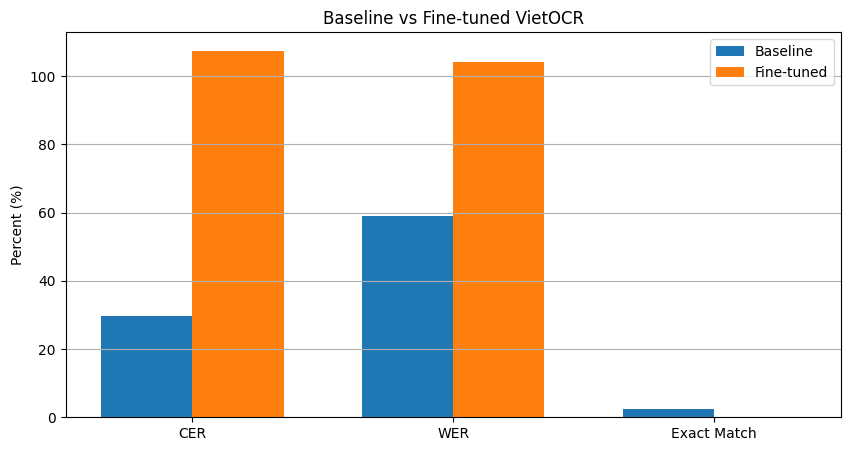

In [20]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

baseline = json.loads(
    Path("runs/baseline-test/metrics.json").read_text()
)

finetuned = json.loads(
    Path("runs/finetuned-test/metrics.json").read_text()
)

names = ["CER", "WER", "Exact Match"]

baseline_values = [
    baseline["cer"] * 100,
    baseline["wer_whitespace"] * 100,
    baseline["exact_match"] * 100,
]

finetuned_values = [
    finetuned["cer"] * 100,
    finetuned["wer_whitespace"] * 100,
    finetuned["exact_match"] * 100,
]

x = np.arange(len(names))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    x - width / 2,
    baseline_values,
    width,
    label="Baseline"
)

plt.bar(
    x + width / 2,
    finetuned_values,
    width,
    label="Fine-tuned"
)

plt.xticks(x, names)
plt.ylabel("Percent (%)")
plt.title("Baseline vs Fine-tuned VietOCR")
plt.legend()
plt.grid(axis="y")

plt.show()

## Đánh giá model của bạn
Cùng manifest với baseline, không gán kết quả baseline cộng đồng thành kết quả model bạn huấn luyện.

# Cell setup

In [23]:
from pathlib import Path
import json
import math
import matplotlib.pyplot as plt

ROOT = Path("/kaggle/working/vietdoc-ocr")

PREP_PATH = ROOT / "data/handwriting/preparation.json"
TRAIN_JSONL = ROOT / "data/handwriting/train.jsonl"
METRICS_JSONL = ROOT / "runs/handwriting/metrics.jsonl"
BASELINE_METRICS = ROOT / "runs/baseline-test/metrics.json"
FINETUNED_METRICS = ROOT / "runs/finetuned-test/metrics.json"

print("ROOT:", ROOT)
print("Preparation exists:", PREP_PATH.exists())
print("Train manifest exists:", TRAIN_JSONL.exists())
print("Training metrics exists:", METRICS_JSONL.exists())
print("Baseline metrics exists:", BASELINE_METRICS.exists())
print("Finetuned metrics exists:", FINETUNED_METRICS.exists())

ROOT: /kaggle/working/vietdoc-ocr
Preparation exists: True
Train manifest exists: True
Training metrics exists: True
Baseline metrics exists: True
Finetuned metrics exists: True


# Vẽ progress của training theo epoch

In [24]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

rows = []
if METRICS_JSONL.exists():
    with METRICS_JSONL.open(encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))

print("Số dòng metrics:", len(rows))
for r in rows[:3]:
    print(r)

Số dòng metrics: 8
{'epoch': 1, 'updates': 1758, 'train_loss': 2.179205588789715, 'samples': 300, 'cer': 1.267089915842315, 'wer_whitespace': 1.370679012345679, 'exact_match': 0.0033333333333333335, 'character_edits': 17164, 'reference_characters': 13546, 'normalization': 'NFC + whitespace collapse; case and diacritics preserved', 'seconds': 162.46270751953125}
{'epoch': 2, 'updates': 3516, 'train_loss': 1.9088920976753034, 'samples': 300, 'cer': 1.307101727447217, 'wer_whitespace': 1.4135802469135803, 'exact_match': 0.0033333333333333335, 'character_edits': 17706, 'reference_characters': 13546, 'normalization': 'NFC + whitespace collapse; case and diacritics preserved', 'seconds': 164.15712523460388}
{'epoch': 3, 'updates': 5274, 'train_loss': 1.8565288898632457, 'samples': 300, 'cer': 1.1917171120626016, 'wer_whitespace': 1.1796296296296296, 'exact_match': 0.0033333333333333335, 'character_edits': 16143, 'reference_characters': 13546, 'normalization': 'NFC + whitespace collapse; case

# Vẽ Training Loss theo Epoch

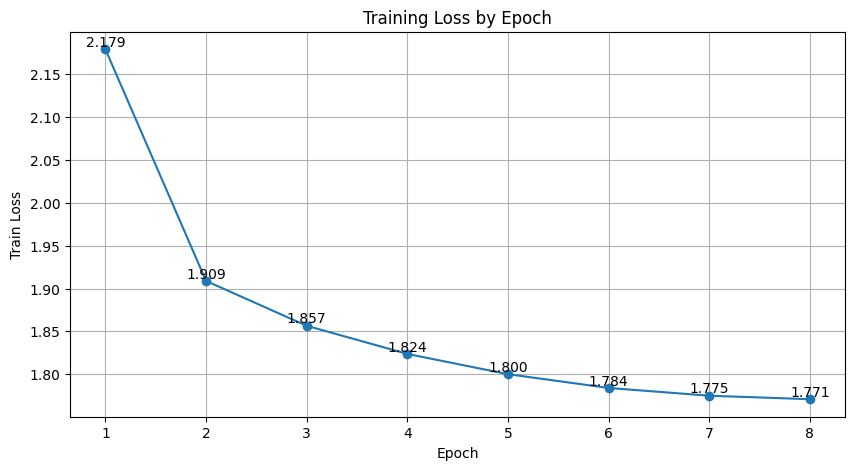

In [25]:
epochs = [r["epoch"] for r in rows if "epoch" in r and "train_loss" in r]
train_loss = [r["train_loss"] for r in rows if "epoch" in r and "train_loss" in r]

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_loss, marker="o")

plt.title("Training Loss by Epoch")
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.xticks(epochs)
plt.grid(True)

for x, y in zip(epochs, train_loss):
    plt.text(x, y, f"{y:.3f}", ha="center", va="bottom")

plt.show()

## Xuất model về local
Tải `handwriting-model.zip`, giải nén để có `models/handwriting/model.pth` và `models/handwriting/config.yml` trên laptop. Khởi động lại ứng dụng.
Tải thêm `runs/baseline-test`, `runs/finetuned-test`, `runs/handwriting/metrics.jsonl` và `data/handwriting/preparation.json` để đưa vào báo cáo.

In [26]:
subprocess.run([sys.executable,'scripts/package_model.py','runs/handwriting','--output','/kaggle/working/handwriting-model.zip'],check=True)
from IPython.display import FileLink, display
display(FileLink('/kaggle/working/handwriting-model.zip'))


/kaggle/working/handwriting-model.zip


/kaggle/working/handwriting-model.zip

In [27]:
!ls -lh /kaggle/working/handwriting-model.zip

-rw-r--r-- 1 root root 136M Sep 15 15:00 /kaggle/working/handwriting-model.zip
